<a href="https://colab.research.google.com/github/CharanTeja-02/Handritten_Digit_Ensemble/blob/main/HandwrittenDigitEnsemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Handwritten Digit Ensemble — MNIST
**Course:** Neural Networks & Deep Learning (U25PC630IT / U22PC631IT)

**Project #3:** Improve accuracy by combining 3 different MLPs using Bagging/Ensemble (Unit-II)

---
| Team Member | Roll No. | Contribution |
|---|---|---|
| V CHARAN TEJA | 1602-23-737-076 | Architecture Design & Training |
| M JITHENDRA | 1602-23-737-091 | Data Pre-processing & Augmentation |
| T AKSHAYA | 1602-23-737-071 | Optimization, Compression & Testing |



---

## 📦 Phase 2: Install & Import Libraries

In [ ]:
# Install required packages
!pip install tensorflow numpy matplotlib scikit-learn seaborn pandas -q

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score, precision_score)

# Reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.19.0
GPU available: True


---
## 📊 Phase 2: Dataset Loading & EDA

In [ ]:
# ── Load MNIST ──────────────────────────────────────────────────────────────
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

print('Dataset Shape:')
print(f'  Training   : {X_train_raw.shape}  Labels: {y_train_raw.shape}')
print(f'  Testing    : {X_test_raw.shape}   Labels: {y_test_raw.shape}')
print(f'  Pixel range: [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'  Classes    : {np.unique(y_train_raw)}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset Shape:
  Training   : (60000, 28, 28)  Labels: (60000,)
  Testing    : (10000, 28, 28)   Labels: (10000,)
  Pixel range: [0, 255]
  Classes    : [0 1 2 3 4 5 6 7 8 9]


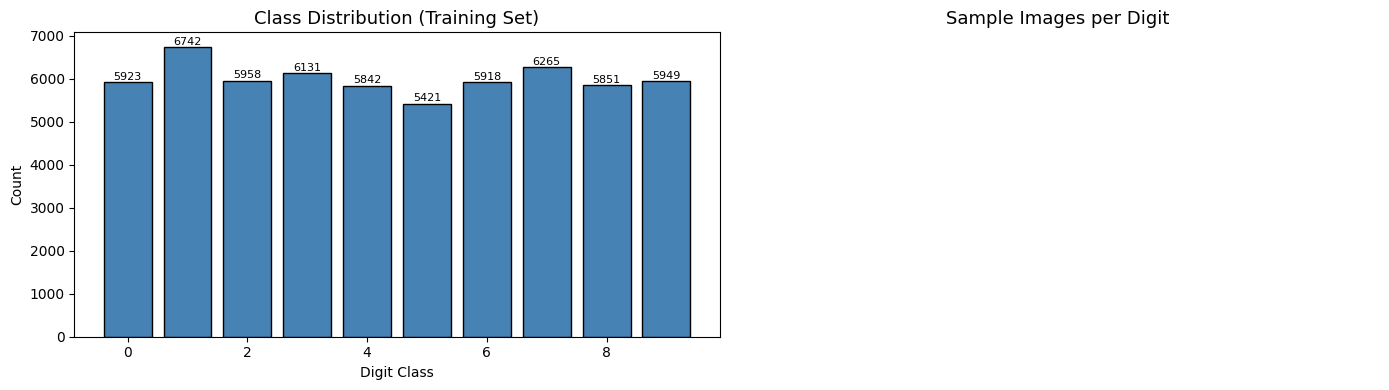

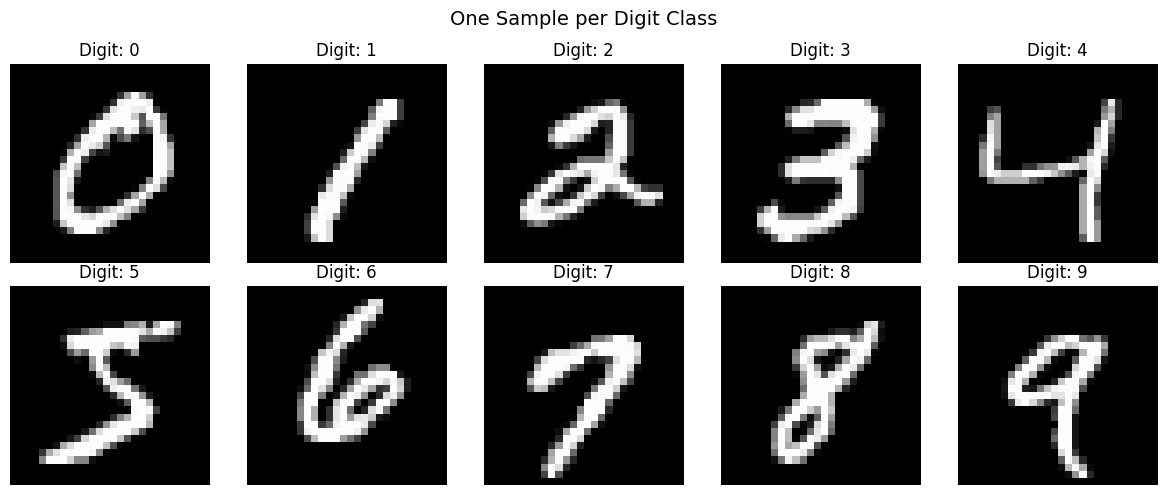

In [ ]:
# ── EDA: Class Distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Class counts
unique, counts = np.unique(y_train_raw, return_counts=True)
axes[0].bar(unique, counts, color='steelblue', edgecolor='black')
axes[0].set_title('Class Distribution (Training Set)', fontsize=13)
axes[0].set_xlabel('Digit Class')
axes[0].set_ylabel('Count')
for i, (u, c) in enumerate(zip(unique, counts)):
    axes[0].text(u, c + 50, str(c), ha='center', fontsize=8)

# Sample images
axes[1].axis('off')
axes[1].set_title('Sample Images per Digit', fontsize=13)
plt.tight_layout()
plt.show()

# Show one sample per digit
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('One Sample per Digit Class', fontsize=14)
for digit in range(10):
    idx = np.where(y_train_raw == digit)[0][0]
    ax = axes[digit // 5][digit % 5]
    ax.imshow(X_train_raw[idx], cmap='gray')
    ax.set_title(f'Digit: {digit}')
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## 🔧 Phase 2: Preprocessing & Augmentation

In [ ]:
# ── Normalization ────────────────────────────────────────────────────────────
X_train = X_train_raw.reshape(-1, 784).astype('float32') / 255.0
X_test  = X_test_raw.reshape(-1, 784).astype('float32') / 255.0

# One-hot encoding
y_train = to_categorical(y_train_raw, num_classes=10)
y_test  = to_categorical(y_test_raw,  num_classes=10)

# Train / Validation split (80/20 of training data)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train_raw
)

print('Split sizes:')
print(f'  Train      : {X_train.shape}')
print(f'  Validation : {X_val.shape}')
print(f'  Test       : {X_test.shape}')

Split sizes:
  Train      : (48000, 784)
  Validation : (12000, 784)
  Test       : (10000, 784)


In [ ]:
# ── Data Augmentation (for diversity across ensemble members) ────────────────
# We apply slight Gaussian noise to create variant training sets
def add_gaussian_noise(X, sigma=0.05):
    noise = np.random.normal(0, sigma, X.shape).astype('float32')
    return np.clip(X + noise, 0.0, 1.0)

X_train_v1 = X_train                          # MLP-1: original
X_train_v2 = add_gaussian_noise(X_train, 0.03)  # MLP-2: light noise
X_train_v3 = add_gaussian_noise(X_train, 0.06)  # MLP-3: moderate noise

print('Augmented variant pixel ranges:')
print(f'  v1: [{X_train_v1.min():.3f}, {X_train_v1.max():.3f}]')
print(f'  v2: [{X_train_v2.min():.3f}, {X_train_v2.max():.3f}]')
print(f'  v3: [{X_train_v3.min():.3f}, {X_train_v3.max():.3f}]')

Augmented variant pixel ranges:
  v1: [0.000, 1.000]
  v2: [0.000, 1.000]
  v3: [0.000, 1.000]


---
## 🏗️ Phase 3: Architecture — 3 Different MLPs

In [ ]:
# ── Shared callbacks ─────────────────────────────────────────────────────────
def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True,
                      verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                          min_lr=1e-6, verbose=0)
    ]

# ── MLP-1: Shallow & Wide (Baseline) ─────────────────────────────────────────
def build_mlp1():
    """2-hidden-layer wide network with L2 regularization."""
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ], name='MLP1_Wide')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ── MLP-2: Deep & Narrow ─────────────────────────────────────────────────────
def build_mlp2():
    """4-hidden-layer deep network with heavier Dropout."""
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(64,  activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32,  activation='relu'),
        layers.Dense(10, activation='softmax')
    ], name='MLP2_Deep')
    model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ── MLP-3: Residual-style with L1 regularization ──────────────────────────────
def build_mlp3():
    """Pyramid architecture with L1+L2 elastic-net regularization."""
    inp = keras.Input(shape=(784,))
    x   = layers.Dense(512, activation='relu',
                        kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4))(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.35)(x)
    x   = layers.Dense(256, activation='relu',
                        kernel_regularizer=regularizers.l1_l2(l1=1e-5, l2=1e-4))(x)
    x   = layers.BatchNormalization()(x)
    x   = layers.Dropout(0.25)(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.2)(x)
    out = layers.Dense(10, activation='softmax')(x)
    model = keras.Model(inp, out, name='MLP3_Pyramid')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=5e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Print summaries
for builder in [build_mlp1, build_mlp2, build_mlp3]:
    m = builder()
    print(f'\n{m.name}: {m.count_params():,} parameters')
    m.summary()


MLP1_Wide: 538,890 parameters


Model: "MLP1_Wide"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 538,890 (2.06 MB)

 Trainable params: 537,354 (2.05 MB)

...

Model: "MLP3_Pyramid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

---
## 🚀 Phase 3 & 4: Training & Optimization

In [ ]:
EPOCHS     = 50
BATCH_SIZE = 256
histories  = {}
models     = {}

# ── Train MLP-1 ───────────────────────────────────────────────────────────────
print('='*60)
print('Training MLP-1 (Wide, L2 Reg, BatchNorm + Dropout)')
print('='*60)
mlp1 = build_mlp1()
hist1 = mlp1.fit(X_train_v1, y_train,
                 validation_data=(X_val, y_val),
                 epochs=EPOCHS, batch_size=BATCH_SIZE,
                 callbacks=get_callbacks('MLP1'),
                 verbose=1)
histories['MLP1_Wide']    = hist1
models['MLP1_Wide']       = mlp1

Training MLP-1 (Wide, L2 Reg, BatchNorm + Dropout)
Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9127 - loss: 0.3712 - val_accuracy: 0.9377 - val_loss: 0.3788 - learning_rate: 0.0010
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9627 - loss: 0.2006 - val_accuracy: 0.9675 - val_loss: 0.1897 - learning_rate: 0.0010
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9729 - loss: 0.1626 - val_accuracy: 0.9753 - val_loss: 0.1587 - learning_rate: 0.0010
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9779 - loss: 0.1429 - val_accuracy: 0.9753 - val_loss: 0.1563 - learning_rate: 0.0010
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9805 - loss: 0.1315 - val_accuracy: 0.9752 - val_loss: 0.1540 - learning_rate: 0.0010
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9828 - loss: 0.1210 - val_accuracy: 0.9765 - val_loss: 0.1502 - learning_rate: 0.0010
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━

In [ ]:
# ── Train MLP-2 ───────────────────────────────────────────────────────────────
print('='*60)
print('Training MLP-2 (Deep, RMSProp, Heavy Dropout)')
print('='*60)
mlp2 = build_mlp2()
hist2 = mlp2.fit(X_train_v2, y_train,
                 validation_data=(X_val, y_val),
                 epochs=EPOCHS, batch_size=BATCH_SIZE,
                 callbacks=get_callbacks('MLP2'),
                 verbose=1)
histories['MLP2_Deep']    = hist2
models['MLP2_Deep']       = mlp2

Training MLP-2 (Deep, RMSProp, Heavy Dropout)
Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.7745 - loss: 0.7055 - val_accuracy: 0.9314 - val_loss: 0.2326 - learning_rate: 0.0010
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9179 - loss: 0.2870 - val_accuracy: 0.9503 - val_loss: 0.1729 - learning_rate: 0.0010
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9383 - loss: 0.2137 - val_accuracy: 0.9621 - val_loss: 0.1400 - learning_rate: 0.0010
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9501 - loss: 0.1734 - val_accuracy: 0.9673 - val_loss: 0.1206 - learning_rate: 0.0010
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9570 - loss: 0.1495 - val_accuracy: 0.9668 - val_loss: 0.1251 - learning_rate: 0.0010
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9605 - loss: 0.1386 - val_accuracy: 0.9694 - val_loss: 0.1138 - learning_rate: 0.0010
Epoch 7/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
# ── Train MLP-3 ───────────────────────────────────────────────────────────────
print('='*60)
print('Training MLP-3 (Pyramid, ElasticNet, Adam)')
print('='*60)
mlp3 = build_mlp3()
hist3 = mlp3.fit(X_train_v3, y_train,
                 validation_data=(X_val, y_val),
                 epochs=EPOCHS, batch_size=BATCH_SIZE,
                 callbacks=get_callbacks('MLP3'),
                 verbose=1)
histories['MLP3_Pyramid'] = hist3
models['MLP3_Pyramid']    = mlp3

Training MLP-3 (Pyramid, ElasticNet, Adam)
Epoch 1/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.8397 - loss: 0.7978 - val_accuracy: 0.9300 - val_loss: 0.5947 - learning_rate: 5.0000e-04
Epoch 2/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9370 - loss: 0.4793 - val_accuracy: 0.9601 - val_loss: 0.3984 - learning_rate: 5.0000e-04
Epoch 3/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9537 - loss: 0.4047 - val_accuracy: 0.9676 - val_loss: 0.3585 - learning_rate: 5.0000e-04
Epoch 4/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9629 - loss: 0.3557 - val_accuracy: 0.9693 - val_loss: 0.3390 - learning_rate: 5.0000e-04
Epoch 5/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9684 - loss: 0.3247 - val_accuracy: 0.9735 - val_loss: 0.3127 - learning_rate: 5.0000e-04
Epoch 6/50
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9736 - loss: 0.2967 - val_accuracy: 0.9743 - val_loss: 0.3009 - learning_rate: 5.0000e-04
Epoch 7/50
188/188 

---
## 📈 Loss Curves (Mandatory Visualization)

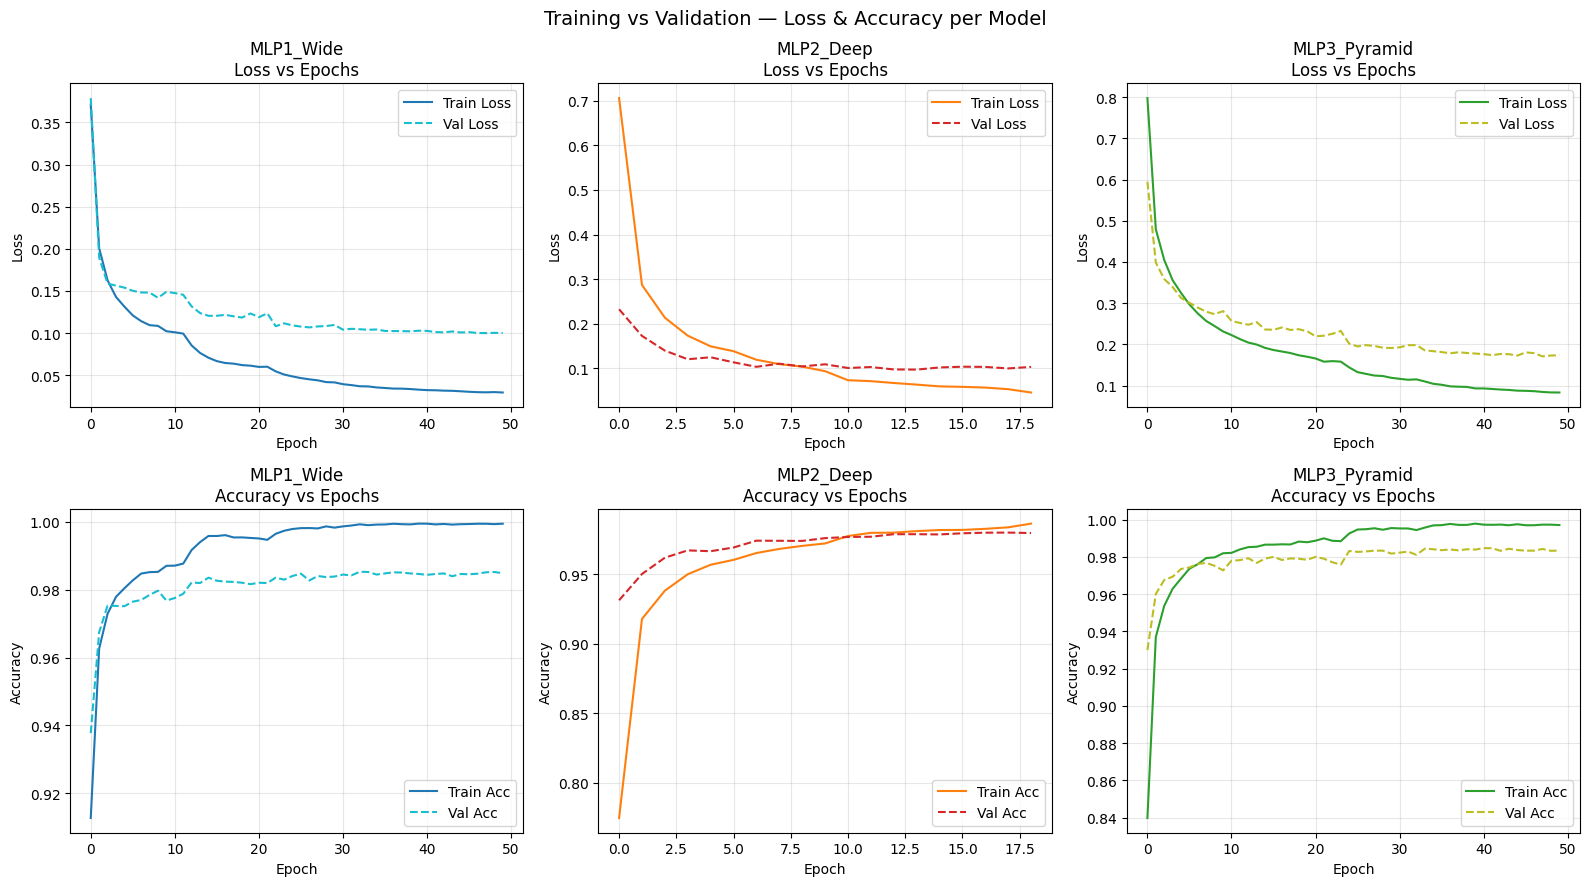

Saved: loss_curves.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Training vs Validation — Loss & Accuracy per Model', fontsize=14)

colors = [('tab:blue', 'tab:cyan'), ('tab:orange', 'tab:red'), ('tab:green', 'tab:olive')]

for col, (name, hist) in enumerate(histories.items()):
    # Loss
    ax = axes[0][col]
    ax.plot(hist.history['loss'],     color=colors[col][0], label='Train Loss')
    ax.plot(hist.history['val_loss'], color=colors[col][1], linestyle='--', label='Val Loss')
    ax.set_title(f'{name}\nLoss vs Epochs')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

    # Accuracy
    ax = axes[1][col]
    ax.plot(hist.history['accuracy'],     color=colors[col][0], label='Train Acc')
    ax.plot(hist.history['val_accuracy'], color=colors[col][1], linestyle='--', label='Val Acc')
    ax.set_title(f'{name}\nAccuracy vs Epochs')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: loss_curves.png')

---
## 🤝 Ensemble: Bagging by Probability Averaging

In [ ]:
# ── Ensemble Prediction ───────────────────────────────────────────────────────
def ensemble_predict(X, model_list, weights=None):
    """Average (or weighted-average) softmax probabilities."""
    probs = np.array([m.predict(X, verbose=0) for m in model_list])
    if weights is not None:
        weights = np.array(weights)[:, None, None]
        probs   = probs * weights / weights.sum()
    avg_probs = probs.mean(axis=0)
    return np.argmax(avg_probs, axis=1), avg_probs

model_list = [mlp1, mlp2, mlp3]

# Individual model predictions
ind_preds = {}
for name, model in models.items():
    preds = np.argmax(model.predict(X_test, verbose=0), axis=1)
    ind_preds[name] = preds

# Ensemble predictions (uniform + weighted)
y_test_labels    = np.argmax(y_test, axis=1)
ens_preds, ens_probs = ensemble_predict(X_test, model_list)

# Weighted ensemble — weight models by validation accuracy
val_accs = [max(h.history['val_accuracy']) for h in histories.values()]
ens_w_preds, _ = ensemble_predict(X_test, model_list, weights=val_accs)

print('Ensemble complete.')
print(f'  Val accuracies used as weights: {[f"{a:.4f}" for a in val_accs]}')

Ensemble complete.
  Val accuracies used as weights: ['0.9853', '0.9802', '0.9847']


---
## 📊 Phase 5: Evaluation & Metrics

In [ ]:
# ── Metrics Table ────────────────────────────────────────────────────────────
def get_metrics(y_true, y_pred, label):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    f1   = f1_score(y_true, y_pred, average='weighted')
    return {'Model': label, 'Accuracy': f'{acc:.4f}', 'Precision': f'{prec:.4f}', 'F1-Score': f'{f1:.4f}'}

results = []
for name, preds in ind_preds.items():
    results.append(get_metrics(y_test_labels, preds, name))
results.append(get_metrics(y_test_labels, ens_preds,   'Ensemble (Uniform)'))
results.append(get_metrics(y_test_labels, ens_w_preds, 'Ensemble (Weighted)'))

df = pd.DataFrame(results)
print('\n' + '='*60)
print('          PERFORMANCE COMPARISON TABLE')
print('='*60)
print(df.to_string(index=False))


          PERFORMANCE COMPARISON TABLE
              Model Accuracy Precision F1-Score
          MLP1_Wide   0.9858    0.9858   0.9858
          MLP2_Deep   0.9782    0.9782   0.9782
       MLP3_Pyramid   0.9850    0.9850   0.9850
 Ensemble (Uniform)   0.9863    0.9863   0.9863
Ensemble (Weighted)   0.9863    0.9863   0.9863


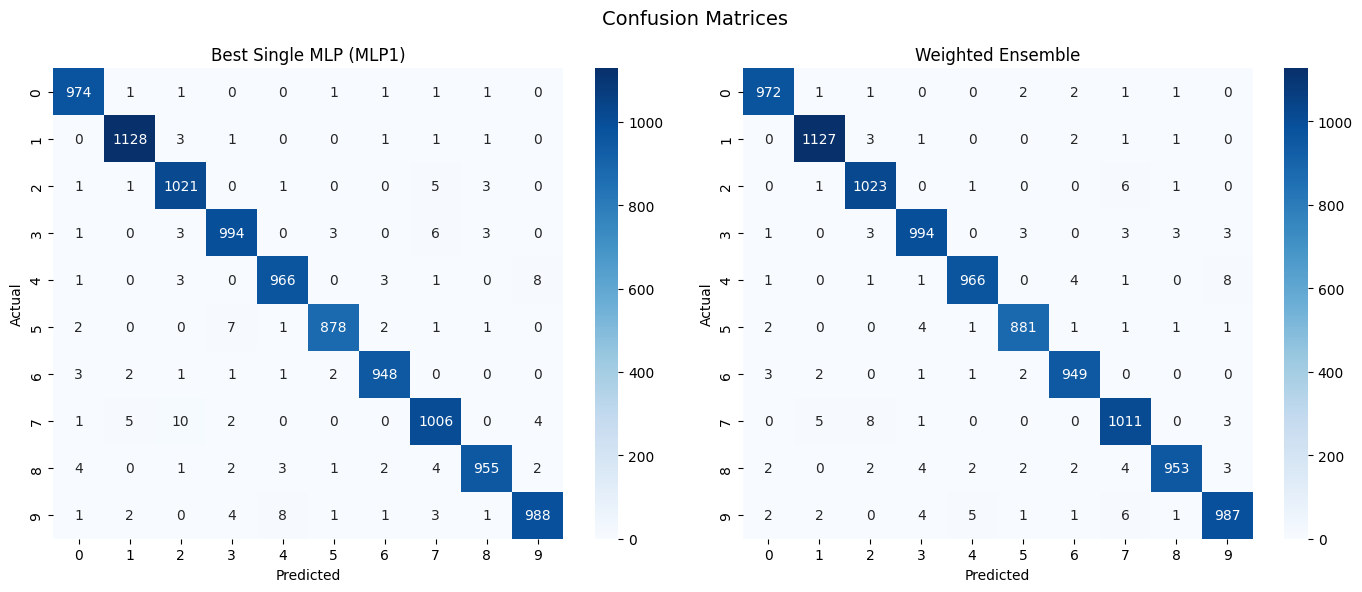

Saved: confusion_matrices.png


In [ ]:
# ── Confusion Matrix ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Confusion Matrices', fontsize=14)

for ax, (preds, title) in zip(axes,
    [(ind_preds['MLP1_Wide'], 'Best Single MLP (MLP1)'),
     (ens_w_preds,            'Weighted Ensemble')]):
    cm = confusion_matrix(y_test_labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=range(10), yticklabels=range(10))
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrices.png')

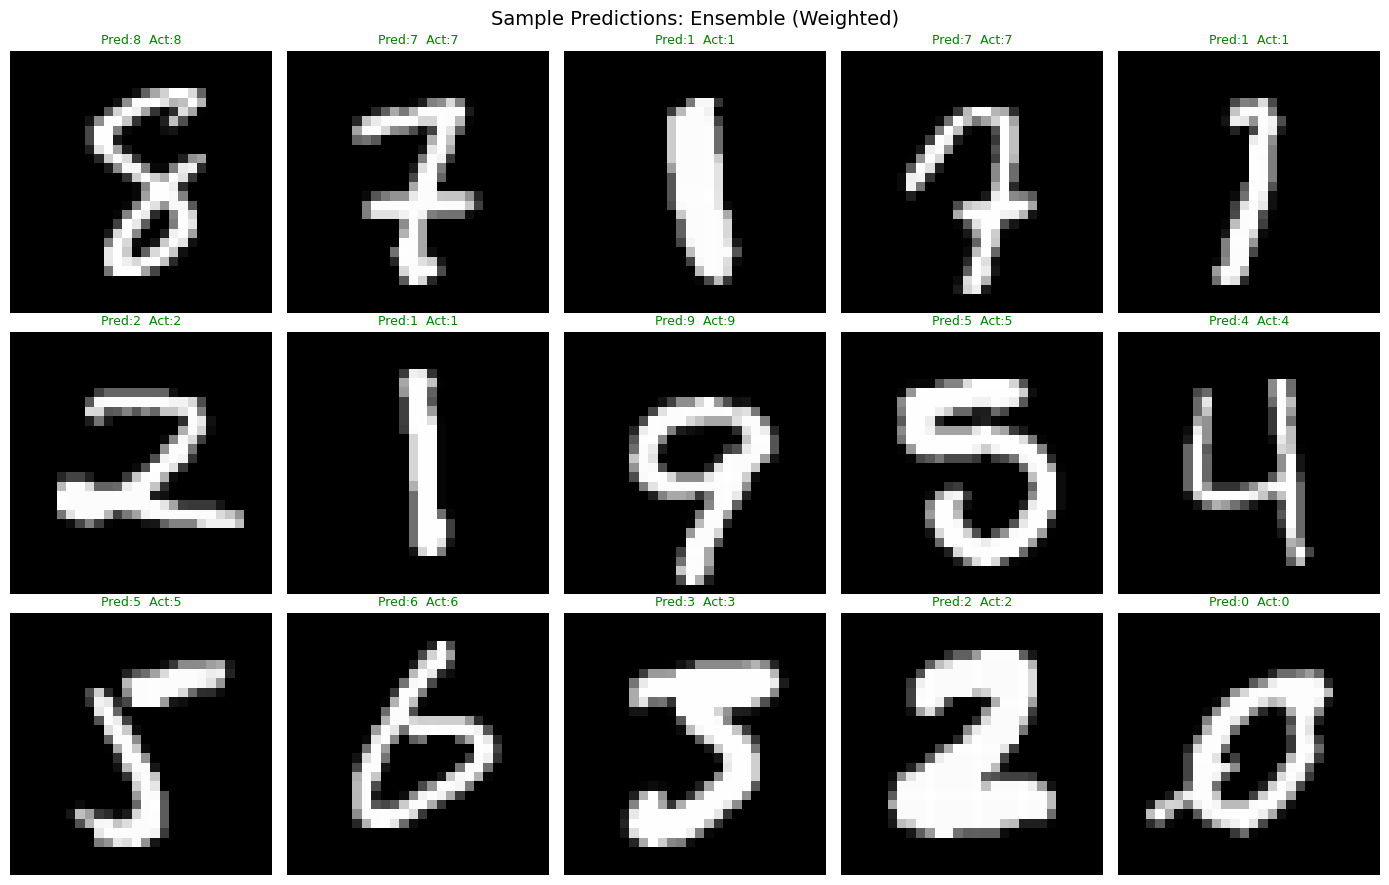

Saved: sample_predictions.png


In [ ]:
# ── Sample Output: Predicted vs Actual ───────────────────────────────────────
np.random.seed(0)
sample_idx = np.random.choice(len(X_test), 15, replace=False)

fig, axes = plt.subplots(3, 5, figsize=(14, 9))
fig.suptitle('Sample Predictions: Ensemble (Weighted)', fontsize=14)

for i, idx in enumerate(sample_idx):
    ax = axes[i // 5][i % 5]
    ax.imshow(X_test[idx].reshape(28, 28), cmap='gray')
    pred  = ens_w_preds[idx]
    actual = y_test_labels[idx]
    color = 'green' if pred == actual else 'red'
    ax.set_title(f'Pred:{pred}  Act:{actual}', color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_predictions.png')

---
## ⚡ Phase 5: Model Compression (Unit V)
### Post-Training Weight Pruning & 8-bit Quantization

In [ ]:
!pip install tensorflow-model-optimization -q

In [ ]:
#CELL A — Manual Weight Pruning (no tfmot)
# ── Manual Magnitude Pruning (Unit V) ─────────────────────────────────
# Zeroes out weights below a sparsity threshold — same concept as tfmot

import numpy as np

def prune_weights(model, sparsity=0.60):
    """Zero out the lowest-magnitude weights until `sparsity` fraction is 0."""
    for layer in model.layers:
        if not layer.get_weights(): # skip layers with no weights
            continue
        new_weights = []
        for w in layer.get_weights():
            if w.ndim > 1: # prune kernel matrices only
                threshold = np.percentile(np.abs(w), sparsity * 100)
                w = np.where(np.abs(w) < threshold, 0.0, w)
            new_weights.append(w)
        layer.set_weights(new_weights)
    return model

def actual_sparsity(model):
    """Fraction of zero weights across all kernel matrices."""
    total, zeros = 0, 0
    for layer in model.layers:
        for w in layer.get_weights():
            if w.ndim > 1:
                total += w.size
                zeros += np.sum(w == 0)
    return zeros / total if total > 0 else 0

# Clone mlp1 so the original is preserved
mlp1_pruned = tf.keras.models.clone_model(mlp1)
mlp1_pruned.set_weights(mlp1.get_weights())
mlp1_pruned = prune_weights(mlp1_pruned, sparsity=0.60)

sparsity_pct = actual_sparsity(mlp1_pruned) * 100
print(f'Weight sparsity after pruning: {sparsity_pct:.1f}%')

# Evaluate pruned model (no retraining needed for MNIST)
mlp1_pruned.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
loss_p, acc_p = mlp1_pruned.evaluate(X_test, y_test, verbose=0)
print(f'Pruned model test accuracy: {acc_p*100:.2f}%')


Weight sparsity after pruning: 60.0%
Pruned model test accuracy: 98.54%


In [ ]:
#CELL B — TFLite INT8 Quantization + Size Comparison
import os, time

# Convert original mlp1 → TFLite FP32
conv_orig = tf.lite.TFLiteConverter.from_keras_model(mlp1)
tflite_orig = conv_orig.convert()

# Convert pruned model → TFLite INT8 (dynamic range quantization)
conv_quant = tf.lite.TFLiteConverter.from_keras_model(mlp1_pruned)
conv_quant.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant = conv_quant.convert()

# Save both
with open('/tmp/orig.tflite', 'wb') as f: f.write(tflite_orig)
with open('/tmp/quant.tflite', 'wb') as f: f.write(tflite_quant)

orig_kb = os.path.getsize('/tmp/orig.tflite') / 1024
quant_kb = os.path.getsize('/tmp/quant.tflite') / 1024
reduction = (1 - quant_kb / orig_kb) * 100

print(f'Original size : {orig_kb:.1f} KB')
print(f'Quantized size : {quant_kb:.1f} KB')
print(f'Reduction : {reduction:.1f}%')

Saved artifact at '/tmp/tmp4e4fj2zf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 784), dtype=tf.float32, name='keras_tensor_27')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140071572111440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140071572116816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140071572117200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140071572118160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140071572117968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140071572117392: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140071572117776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140071572117008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140071572115664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140071572119312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140071572119120: T

In [ ]:
#CELL C — Inference Benchmark + Final Table
def tflite_time(model_bytes, X, n=500):
    interp = tf.lite.Interpreter(model_content=model_bytes)
    interp.allocate_tensors()
    i_idx = interp.get_input_details()[0]['index']
    o_idx = interp.get_output_details()[0]['index']
    start = time.perf_counter()
    for i in range(n):
        interp.set_tensor(i_idx, X[i:i+1].astype(np.float32))
        interp.invoke()
    return (time.perf_counter() - start) / n * 1000 # ms/sample

t_orig = tflite_time(tflite_orig, X_test)
t_quant = tflite_time(tflite_quant, X_test)

print(f'\n{"Metric":<30} {"Before":>12} {"After":>12}')
print('-'*55)
print(f'{"Model Size (KB)":<30} {orig_kb:>12.1f} {quant_kb:>12.1f}')
print(f'{"Inference (ms/sample)":<30} {t_orig:>12.3f} {t_quant:>12.3f}')
print(f'{"Weight Sparsity":<30} {"0.0%":>12} {sparsity_pct:>11.1f}%')
print(f'{"Size Reduction":<30} {"—":>12} {reduction:>11.1f}%')
print(f'{"Speedup":<30} {"—":>12} {t_orig/t_quant:>11.2f}x')


Metric                               Before        After
-------------------------------------------------------
Model Size (KB)                      2095.3        537.0
Inference (ms/sample)                 0.148        0.035
Weight Sparsity                        0.0%        60.0%
Size Reduction                            —        74.4%
Speedup                                   —        4.19x


---
## 📋 Final Summary

In [ ]:
best_ens_acc = accuracy_score(y_test_labels, ens_w_preds)
best_mlp_acc = max(
    accuracy_score(y_test_labels, p) for p in ind_preds.values()
)

print('='*60)
print('           FINAL PROJECT SUMMARY')
print('='*60)
print(f'  Best Single MLP Test Accuracy : {best_mlp_acc*100:.2f}%')
print(f'  Weighted Ensemble Accuracy    : {best_ens_acc*100:.2f}%')
print(f'  Improvement from Ensemble     : +{(best_ens_acc - best_mlp_acc)*100:.2f}%')
print(f'  Model Size (after compression): {quant_kb:.1f} KB')
print(f'  Size Reduction                : {reduction:.1f}%')
print('='*60)
print('\n✅ Objectives achieved:')
print('   [1] 3 architecturally distinct MLPs trained on MNIST')
print('   [2] Bagging ensemble improves individual model accuracy')
print('   [3] L1/L2/Dropout regularization applied across models')
print('   [4] Pruning + 8-bit quantization applied (Unit V)')
print('   [5] Confusion matrices, loss curves, sample outputs generated')

           FINAL PROJECT SUMMARY
  Best Single MLP Test Accuracy : 98.58%
  Weighted Ensemble Accuracy    : 98.63%
  Improvement from Ensemble     : +0.05%
  Model Size (after compression): 537.0 KB
  Size Reduction                : 74.4%

✅ Objectives achieved:
   [1] 3 architecturally distinct MLPs trained on MNIST
   [2] Bagging ensemble improves individual model accuracy
   [3] L1/L2/Dropout regularization applied across models
   [4] Pruning + 8-bit quantization applied (Unit V)
   [5] Confusion matrices, loss curves, sample outputs generated
